# 机器学习大作业大概步骤

### 任务：按类别进行二分类情感分析
目标： 对每个类别进行二分类情感分析，分别预测每个类别的评论是否为正向或负向。

数据划分

按照类别将数据集划分为 10 个子数据集（每个类别的数据）

数据处理

对每个子数据集进行文本预处理，生成特征

对每个子数据集的 label 进行二分类处理（1 为正向，0 为负向）

选择模型

为每个子任务选择分类模型，如：

逻辑回归（Logistic Regression）

支持向量机（SVM）

随机森林（Random Forest）

XGBoost

训练与评估

对每个类别的模型进行训练和评估

使用准确率、精确度、召回率、F1-score 等指标进行评估

模型调优与测试

为每个类别的模型调优

测试每个模型的表现，并进行部署

## 4.任务开始
### (1)数据集搜索与理解

数据集介绍：对数据集的来源、内容、字段进行详细描述，确保理解数据集的结构和特征。可以简要说明数据的性质、类别以及数据的规模。

数据集概述：该数据集包含 10 个类别（书籍、平板、手机、水果、洗发水、热水器、蒙牛、衣服、计算机、酒店），共 6 万多条评论数据，正向和负向评论各约 3 万条。

字段描述：

cat: 类别标签（10个类别）

label: 1 表示正向评论，0 表示负向评论

review: 评论内容

In [ ]:
import os
import pandas as pd

# 设置数据路径（相对路径）
data_dir   = "shopping_comments"  # 数据文件夹名称
train_path = os.path.join(data_dir, "train.txt")  # 训练集文件路径

In [2]:
#查看数据文件目录
df = pd.read_csv(
    train_path,
    sep='\t',
    names=['label', 'review'],  # 这里只有两个字段
    quoting=3,                   # csv.QUOTE_NONE
    encoding='utf-8'
)
print("样本数：", len(df))
df.head()

样本数： 50220


,label,review
0,label,text_a
1,1,布料一般，尺码合适，总体来说还算可以
2,0,这次购买太失败了，等了那么久才到，哎，希望京东可以自我检讨一下
3,0,一点都不好用，第一次用，洗了头上感觉油油的，超级超级不喜欢，估计要丢了
4,1,裤子收到了 质量超级好 穿起来也很正式男朋友很喜欢


#### 定义关键词匹配规则(已经迭代过四次)

In [ ]:
# 4. 定义关键词匹配规则
# 使用关键词字典将评论文本映射到10个商品类别
# 结构：{关键词: 对应类别}，遍历时按顺序匹配，先匹配到的优先
keyword_cat_map = {
    # 手机类：包含手机品牌和手机相关功能关键词
    '手机': '手机', '华为': '手机', '苹果手机': '手机', '小米': '手机', '荣耀': '手机',
    '信号': '手机', '电池': '手机', '通话': '手机', '充电': '手机', '拍照': '手机', '屏幕': '手机', '系统': '手机',

    # 洗发水类：包含洗护产品和头发相关关键词
    '洗发水': '洗发水', '洗头': '洗发水', '头发': '洗发水', '头皮': '洗发水', '清洁': '洗发水',
    '油油的': '洗发水', '不喜欢': '洗发水', '洗发': '洗发水', '味道': '洗发水', '好用': '洗发水',

    # 衣服类：包含服装和穿着相关关键词
    '裤子': '衣服', '衣服': '衣服', '尺码': '衣服', '上衣': '衣服', '裙子': '衣服', '布料': '衣服',
    '合身': '衣服', '颜色': '衣服', '外观': '衣服', '品牌': '衣服', '穿起来': '衣服', '好看': '衣服',

    # 书籍类：包含图书和阅读相关关键词
    '书': '书籍', '小说': '书籍', '阅读': '书籍', '教材': '书籍', '读物': '书籍', '封面': '书籍',
    '质量': '书籍', '包装': '书籍',

    # 热水器类：包含热水器产品和使用场景关键词
    '热水器': '热水器', '热水': '热水器', '电热水器': '热水器', '洗澡': '热水器', '水温': '热水器',

    # 平板类：包含平板电脑产品关键词
    '平板': '平板', 'iPad': '平板', '平板电脑': '平板', '安卓平板': '平板', '触控': '平板', '画图': '平板',
    '学习': '平板', '性能': '平板',

    # 水果类：包含常见水果名称和品质描述关键词
    '水果': '水果', '苹果': '水果', '香蕉': '水果', '橙子': '水果', '西瓜': '水果', '芒果': '水果',
    '新鲜': '水果', '好吃': '水果', '便宜': '水果',

    # 蒙牛类：包含蒙牛品牌和乳制品相关关键词
    '蒙牛': '蒙牛', '牛奶': '蒙牛', '酸奶': '蒙牛', '拉肚子': '蒙牛', '乳制品': '蒙牛',
    '肚子痛': '蒙牛', '味道': '蒙牛', '新鲜': '蒙牛', '好吃': '蒙牛',

    # 酒店类：包含住宿和服务相关关键词
    '酒店': '酒店', '住宿': '酒店', '宾馆': '酒店', '旅店': '酒店', '前台': '酒店', '服务': '酒店',
    '房间': '酒店', '性价比': '酒店', '卫生': '酒店',

    # 计算机类：包含电脑硬件和产品相关关键词
    '电脑': '计算机', '笔记本': '计算机', '台式机': '计算机', '处理器': '计算机', '主板': '计算机',
    '内存': '计算机', 'CPU': '计算机', '显卡': '计算机', '使用': '计算机', '做工': '计算机', '产品': '计算机', '系统': '计算机'
}

In [ ]:
# 5. 定义关键词匹配分类函数（带类型转换）
def keyword_based_cat(text):
    """遍历关键词字典，将评论文本映射到对应的商品类别"""
    text = str(text)  # 防止空值或数字，统一转为字符串
    for keyword, cat in keyword_cat_map.items():
        if keyword in text:  # 如果评论中包含该关键词
            return cat       # 返回对应类别
    return '未知'            # 没有匹配到任何关键词则标记为"未知"

In [6]:
# 6. 添加分类列
df['cat'] = df['review'].apply(keyword_based_cat)




In [7]:
# 7. 查看结果
print("\n加标签后的前几条：")
print(df.head())




加标签后的前几条：
   label                               review  cat
0  label                               text_a   未知
1      1                   布料一般，尺码合适，总体来说还算可以   衣服
2      0      这次购买太失败了，等了那么久才到，哎，希望京东可以自我检讨一下   未知
3      0  一点都不好用，第一次用，洗了头上感觉油油的，超级超级不喜欢，估计要丢了  洗发水
4      1            裤子收到了 质量超级好 穿起来也很正式男朋友很喜欢   衣服


In [8]:
# 8. 类别分布统计（可视化准备）
print("\n每类评论数量：")
print(df['cat'].value_counts())

df[df['cat'] == '未知']['review'].sample(20).tolist()



每类评论数量：
cat
未知     14815
酒店      6152
书籍      5595
衣服      5218
手机      4780
蒙牛      3783
水果      3764
洗发水     3303
计算机     1931
平板       536
热水器      343
Name: count, dtype: int64


['送货很快 没有任何小票或商品吊牌 不知道是不是正品 用后再来追评',
 '根本没有货说有货，等了六天才发货，如果不是因为次日达也不会买你的，结果比任何一家电商都慢。咨询客服，客服的回应更气人，第一次告诉我有货，会马上发货，两天后再次咨询告诉我是预售，我问哪里显示是预售，只会让你等，无语了，这客服的态度还不如没有呢。',
 '一洗就皱在一起了，不好',
 '一颗星都不想给！客服真的一点都不专业。快递垃圾死了。就在昆明本地。走了五天。还是我自己上门区的！',
 '订单时间错误，住不了，让其他朋友去住。结果390的房费连窗户都没有，携程介绍中也没有说明，很不满意。差评！',
 '差评，不仅到货时间长，到了以后破损，必须差评',
 '通过携程预定的行政双床房(且提前付清房费)~最后居然给我们父女两人一间大床房~还一再申明没有双床房了~在我的一再要求下~最后虽然还是提供了双床房~但是印象大打折扣~补充点评 2008年3月24日 ： 温泉~住店客人是98/位~小鱼池是46~另外收费的~',
 '算起来比超市还要更贵表面写的好满188减100实际上比超市还贵',
 '不支持自动开关机',
 '很差、这么贵的价格设备配置差也就算了、马桶套圈裂的、把我大腿肉夹了好几次',
 '京东自营的就是货真价实！！！',
 '地理位置好。其余乏善可陈。班车接送也很方便。',
 '清扬推荐同事们买的，一直用着都挺不错',
 '不好。到了已经有一个烂了。而且有些甜有些不甜。下次不买这家的了。',
 '东西收到，还没试用，希望是正品。怎么没有吹风呢？',
 '哎，，，寄错地址了。。。',
 '太小，没法穿，儿子穿都小，',
 '收到商品与图片不相符',
 '还不错。。。',
 '不是说有吹风机送么？？？买了两套连个毛也没送']

#### 把“未知”内容中top50的关键词提取出来

In [ ]:
import pandas as pd
import jieba
from collections import Counter

# 读取数据
df = pd.read_csv(train_path, sep='\t', names=['label', 'review'], quoting=3, encoding='utf-8')

# 复用之前的分类规则（与上方keyword_cat_map相同）
category_keywords = {
   # 手机
    '手机': '手机', '华为': '手机', '苹果手机': '手机', '小米': '手机', '荣耀': '手机',
    '信号': '手机', '电池': '手机', '通话': '手机', '充电': '手机', '拍照': '手机', '屏幕': '手机', '系统': '手机',

    # 洗发水
    '洗发水': '洗发水', '洗头': '洗发水', '头发': '洗发水', '头皮': '洗发水', '清洁': '洗发水',
    '油油的': '洗发水', '不喜欢': '洗发水', '洗发': '洗发水', '味道': '洗发水', '好用': '洗发水',

    # 衣服
    '裤子': '衣服', '衣服': '衣服', '尺码': '衣服', '上衣': '衣服', '裙子': '衣服', '布料': '衣服',
    '合身': '衣服', '颜色': '衣服', '外观': '衣服', '品牌': '衣服', '穿起来': '衣服', '好看': '衣服',

    # 书籍
    '书': '书籍', '小说': '书籍', '阅读': '书籍', '教材': '书籍', '读物': '书籍', '封面': '书籍',
    '质量': '书籍', '包装': '书籍',

    # 热水器
    '热水器': '热水器', '热水': '热水器', '电热水器': '热水器', '洗澡': '热水器', '水温': '热水器',

    # 平板
    '平板': '平板', 'iPad': '平板', '平板电脑': '平板', '安卓平板': '平板', '触控': '平板', '画图': '平板',
    '学习': '平板', '性能': '平板',

    # 水果
    '水果': '水果', '苹果': '水果', '香蕉': '水果', '橙子': '水果', '西瓜': '水果', '芒果': '水果',
    '新鲜': '水果', '好吃': '水果', '便宜': '水果',

    # 蒙牛
    '蒙牛': '蒙牛', '牛奶': '蒙牛', '酸奶': '蒙牛', '拉肚子': '蒙牛', '乳制品': '蒙牛',
    '肚子痛': '蒙牛', '味道': '蒙牛', '新鲜': '蒙牛', '好吃': '蒙牛',

    # 酒店
    '酒店': '酒店', '住宿': '酒店', '宾馆': '酒店', '旅店': '酒店', '前台': '酒店', '服务': '酒店',
    '房间': '酒店', '性价比': '酒店', '卫生': '酒店',

    # 计算机
    '电脑': '计算机', '笔记本': '计算机', '台式机': '计算机', '处理器': '计算机', '主板': '计算机',
    '内存': '计算机', 'CPU': '计算机', '显卡': '计算机', '使用': '计算机', '做工': '计算机', '产品': '计算机', '系统': '计算机'
}

# 分类函数：遍历每个类别的关键词列表，任意一个命中即归类
def classify_category(text):
    for cat, keywords in category_keywords.items():
        if any(k in str(text) for k in keywords):
            return cat
    return "未知"

# 对全部评论进行分类
df['cat'] = df['review'].apply(classify_category)

# 仅提取"未知"评论，用于分析遗漏情况
unknown_reviews = df[df['cat'] == '未知']['review'].dropna().astype(str)

# 加载停用词表（过滤高频无意义词）
stopwords = set([
    '的', '了', '和', '是', '在', '也', '都', '就', '很', '呢', '啊',
    '又', '还', '买', '个', '有', '用', '还行', '不错', '不行', '一个'
])

# 对"未知"评论进行jieba分词并统计高频词
all_words = []
for review in unknown_reviews:
    words = jieba.lcut(review)                              # jieba中文分词
    words = [w for w in words if w not in stopwords and len(w) > 1]  # 过滤停用词和单字符
    all_words.extend(words)

# 高频词统计：找出"未知"评论中的共性关键词
word_freq = Counter(all_words)
top_words = word_freq.most_common(100)  # 取前100个高频词

# 输出结果：用于迭代优化关键词匹配规则
print("未知类别评论中高频关键词（前100）：\n")
for word, count in top_words:
    print(f"{word}: {count}")

### （2）数据清洗
• 去除无关字符（如HTML标签、特殊符号）。

• 处理缺失值（如删除或填充）。

• 文本预处理（分词、去除停用词、词干提取）。

• 清洗前后对比：通过可视化展示清洗前后的数据分布变化

数据清洗步骤：

缺失值处理：检查 cat、label 和 review 列是否有缺失值，处理缺失数据（可以填充或删除缺失值，取决于具体情况）。

重复数据处理：检查是否有重复评论，如果有，去除重复数据。

文本预处理：对评论（review）进行文本预处理：

去除停用词

小写化

去除标点符号

词形还原或词干提取

数据可视化：清洗前后，展示数据的分布（如类别分布、情感分布等），使用柱状图、饼图等。

展示清洗前后的数据分布图（如 matplotlib 或 seaborn 进行可视化）


In [ ]:
# 数据清洗与可视化管道
import os
import warnings
import pandas as pd
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup, MarkupResemblesLocatorWarning  # HTML解析库
import jieba       # 中文分词工具
import re          # 正则表达式
import string
from matplotlib import rcParams

# 忽略 BeautifulSoup 的文件路径警告（当输入不是HTML时触发）
warnings.filterwarnings("ignore", category=MarkupResemblesLocatorWarning)

# 设置中文字体，解决matplotlib中文乱码问题
rcParams['font.sans-serif'] = ['SimHei']
rcParams['axes.unicode_minus'] = False  # 解决负号显示为方块的问题

In [12]:
# 1. 读取数据
data_path = "shopping_comments/train.txt"  # 直接写相对路径
df = pd.read_csv(
    data_path,
    sep='\t',
    names=['label', 'review'],
    quoting=3,
    encoding='utf-8'
)

In [13]:
# 2. 初步统计（清洗前）
print("清洗前样本数：", len(df))
print("缺失值情况：")
print(df.isnull().sum())
print("重复评论数：", df.duplicated(subset=['review']).sum())


清洗前样本数： 50220
缺失值情况：
label     0
review    1
dtype: int64
重复评论数： 30


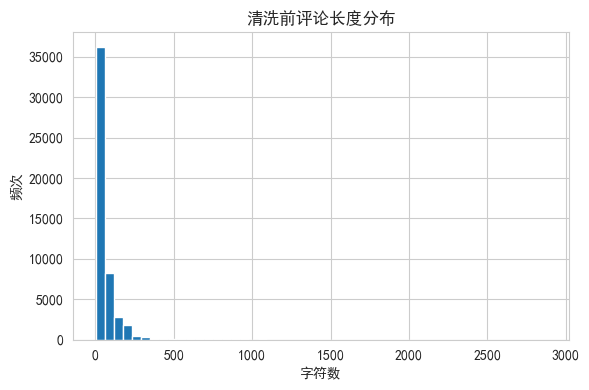

In [14]:
# 分布可视化——评论长度分布
lengths_before = df['review'].dropna().map(len)
plt.figure(figsize=(6,4))
plt.hist(lengths_before, bins=50)
plt.title('清洗前评论长度分布')
plt.xlabel('字符数')
plt.ylabel('频次')
plt.tight_layout()
plt.show()

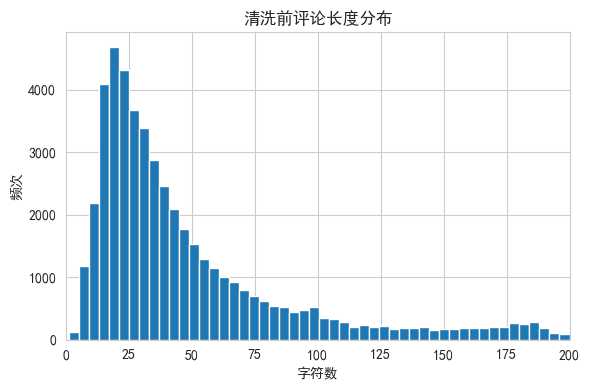

In [15]:
# 过滤掉长度超过200的评论
lengths_before = df['review'].dropna()[df['review'].dropna().map(len) <= 200].map(len)

plt.figure(figsize=(6,4))
plt.hist(lengths_before, bins=50)
plt.title('清洗前评论长度分布')
plt.xlabel('字符数')
plt.ylabel('频次')

# 设置x轴范围为0-200
plt.xlim(0, 200)
plt.tight_layout()
plt.show()

In [16]:
# 3. 缺失值与重复值处理
df = df.dropna(subset=['review']).drop_duplicates(subset=['review']).reset_index(drop=True)

In [17]:
# 4. 加载停用词表（存在则读取，否则使用默认）
try:
    with open('stopwords.txt', encoding='utf-8') as f:
        stopwords = set(line.strip() for line in f if line.strip())
except FileNotFoundError:
    # 默认中文停用词示例
    stopwords = set(["的","了","在","是","我","有","和","也","就","不","人","都","一","一个","上","说","就","还","要","为","等","与","着","这","那"])


In [18]:
# 5. 文本预处理函数
def clean_text(text):
    # 去除 HTML 标签
    text = BeautifulSoup(str(text), 'lxml').get_text()
    # 小写化
    text = text.lower()
    # 去除特殊符号，仅保留中文、英文字母、数字
    text = re.sub(r"[^一-鿿A-Za-z0-9]", " ", text)
    # 分词
    tokens = jieba.lcut(text)
    # 去停用词与单字符
    tokens = [w for w in tokens if w not in stopwords and len(w) > 1]
    return " ".join(tokens)

In [19]:
# 应用清洗
df['clean_review'] = df['review'].apply(clean_text)

清洗后样本数： 50189


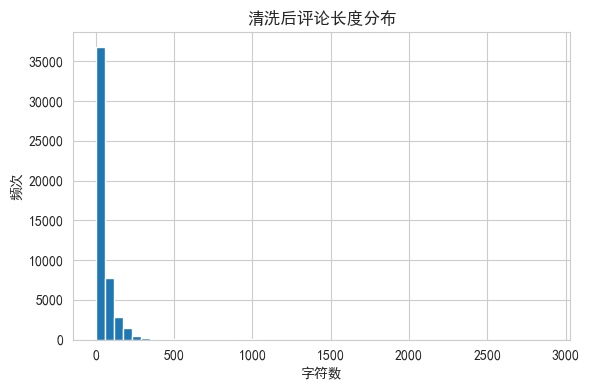

In [20]:
# 6. 清洗后统计与可视化
print("清洗后样本数：", len(df))

lengths_after = df['clean_review'].map(len)
plt.figure(figsize=(6,4))
plt.hist(lengths_after, bins=50)
plt.title('清洗后评论长度分布')
plt.xlabel('字符数')
plt.ylabel('频次')
plt.tight_layout()
plt.show()

清洗后样本数： 48480


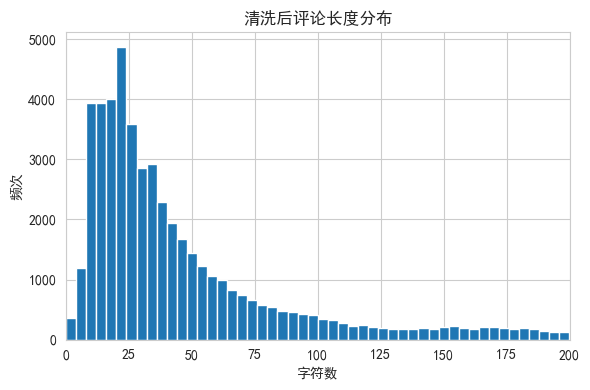

In [21]:
# 过滤掉长度超过200的评论
df_cleaned = df[df['clean_review'].map(len) <= 200]

# 打印清洗后的样本数
print("清洗后样本数：", len(df_cleaned))

# 计算清洗后评论的长度
lengths_after = df_cleaned['clean_review'].map(len)

# 绘制直方图
plt.figure(figsize=(6,4))
plt.hist(lengths_after, bins=50)
plt.title('清洗后评论长度分布')
plt.xlabel('字符数')
plt.ylabel('频次')

# 显式设置x轴范围为0-200
plt.xlim(0, 200)
plt.tight_layout()
plt.show()

In [22]:
# 7. 清洗前后示例展示
print(df[['review', 'clean_review']].head(5).to_string(index=False))

                             review                    clean_review
                             text_a                            text
                 布料一般，尺码合适，总体来说还算可以            布料 一般 尺码 合适 总体 来说 可以
    这次购买太失败了，等了那么久才到，哎，希望京东可以自我检讨一下    这次 购买 失败 那么 希望 京东 可以 自我检讨 一下
一点都不好用，第一次用，洗了头上感觉油油的，超级超级不喜欢，估计要丢了 一点 不好 第一次 头上 感觉 油油的 超级 超级 喜欢 估计
          裤子收到了 质量超级好 穿起来也很正式男朋友很喜欢        裤子 收到 质量 超级 起来 正式 男朋友 喜欢


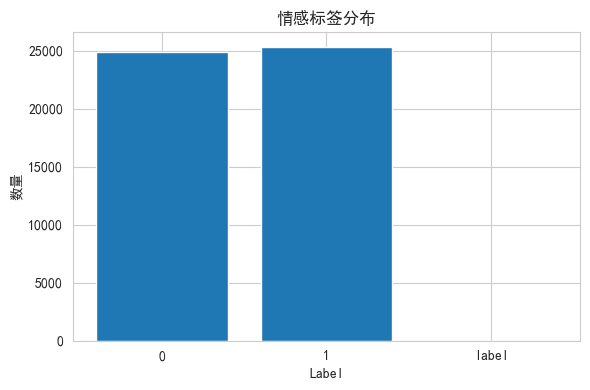

In [23]:
# 8. 情感标签分布（清洗后）
counts_label = df['label'].value_counts().sort_index()
plt.figure(figsize=(6,4))
plt.bar(counts_label.index.astype(str), counts_label.values)
plt.title('情感标签分布')
plt.xlabel('Label')
plt.ylabel('数量')
plt.tight_layout()
plt.show()


###  （3）特征工程
• 词袋模型（Bag of Words）：使用`CountVectorizer`提取词频特征。

• TF-IDF：使用`TfidfVectorizer`提取TF-IDF特征。
特征提取：

词袋模型：使用 CountVectorizer 对文本进行词袋模型转换。

TF-IDF：使用 TfidfVectorizer 对文本进行 TF-IDF 特征提取。

词向量：可以使用预训练的词向量（如Word2Vec）进行特征提取，或者通过 spaCy 等库进行词向量表示。

创新性特征提取：在词袋和 TF-IDF 基础上，使用词向量进行特征提取，并结合不同特征模型的结果进行合并，探索其对模型效果的提升。

数据可视化：展示特征提取前后的样本数据，以及不同特征提取方法的效果。



In [24]:
# 3. 特征工程 —— 词袋、TF-IDF 与词向量
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import PCA
from scipy.sparse import hstack
from gensim.models import Word2Vec
import jieba

In [26]:
data_path = "shopping_comments/train.txt"  # 使用正斜杠，Windows也支持
# 或 "shopping_comments\\train.txt"  # 原始Windows风格
# 或 "./shopping_comments/train.txt"  # 显式表示当前目录

df = pd.read_csv(data_path, sep='\t', names=['label','review'], quoting=3, encoding='utf-8')
df['clean_review'] = df['review'].apply(clean_text)

In [27]:
# 词袋模型（CountVectorizer）
bow_vect = CountVectorizer(max_features=5000)#对关键词的term frequency进行降序排序，取前5000个作为关键词
X_bow = bow_vect.fit_transform(df['clean_review'])#变成文本矩阵
print("BoW 特征矩阵形状：", X_bow.shape)

BoW 特征矩阵形状： (50220, 5000)


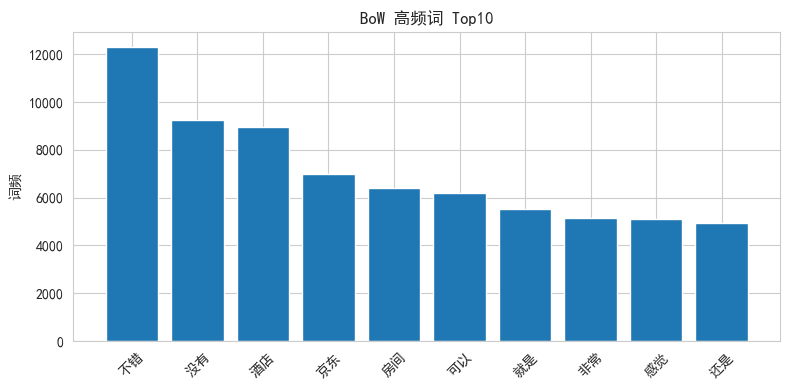

In [28]:
# 可视化 BoW 高频词 Top10
bow_sum = np.array(X_bow.sum(axis=0)).ravel()
bow_idx = np.argsort(bow_sum)[-10:][::-1]
bow_terms = np.array(bow_vect.get_feature_names_out())[bow_idx]
bow_counts = bow_sum[bow_idx]

plt.figure(figsize=(8,4))
plt.bar(bow_terms, bow_counts)
plt.xticks(rotation=45)
plt.title('BoW 高频词 Top10')
plt.ylabel('词频')
plt.tight_layout()
plt.show()

In [29]:
# TF-IDF 特征（TfidfVectorizer）
tfidf_vect = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf_vect.fit_transform(df['clean_review'])
print("TF-IDF 特征矩阵形状：", X_tfidf.shape)

TF-IDF 特征矩阵形状： (50220, 5000)


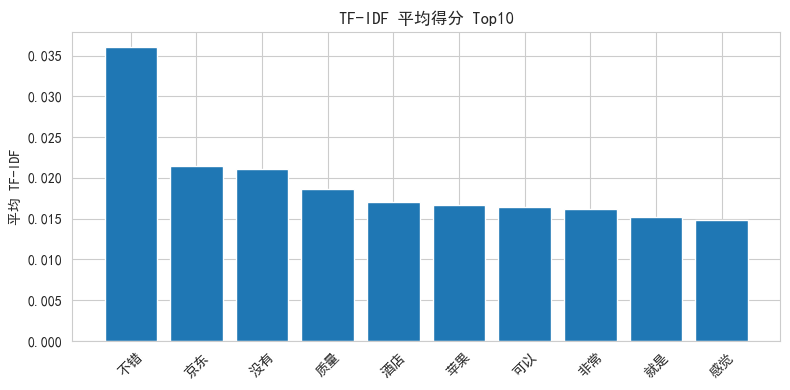

In [30]:
# 可视化 TF-IDF 平均值 Top10
tfidf_mean = np.array(X_tfidf.mean(axis=0)).ravel()
tfidf_idx = np.argsort(tfidf_mean)[-10:][::-1]
tfidf_terms = np.array(tfidf_vect.get_feature_names_out())[tfidf_idx]
tfidf_scores = tfidf_mean[tfidf_idx]

plt.figure(figsize=(8,4))
plt.bar(tfidf_terms, tfidf_scores)
plt.xticks(rotation=45)
plt.title('TF-IDF 平均得分 Top10')
plt.ylabel('平均 TF-IDF')
plt.tight_layout()
plt.show()

#### 词向量要用到神经网络的方法，暂时空着

###  (4)模型的选择与判断
• 情感分类：

• 使用逻辑回归、朴素贝叶斯等模型进行训练。

• 评估模型性能（准确率、精确率、召回率、F1分数）。

选择分类器

使用多种分类器：

支持向量机（SVM）：使用 SVC 或 LinearSVC。

K最近邻（KNN）：使用 KNeighborsClassifier。

贝叶斯分类器：使用 MultinomialNB。

In [31]:
print(df['label'].value_counts())


label
1        25327
0        24892
label        1
Name: count, dtype: int64


In [32]:
# 删除样本数小于2的类
label_counts = df['label'].value_counts()
valid_labels = label_counts[label_counts >= 2].index
df = df[df['label'].isin(valid_labels)].reset_index(drop=True)


In [33]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt


In [34]:
# 1. 确保标签为整数类型
y = df['label'].astype(int)
X = df['clean_review']

In [35]:
# 2. 特征提取（词袋模型）
vectorizer = CountVectorizer()
X_vectorized = vectorizer.fit_transform(X)

In [36]:
# 3. 划分训练测试集
X_train, X_test, y_train, y_test = train_test_split(X_vectorized, y, test_size=0.2, stratify=y, random_state=42)

In [37]:
# 4. 分类器字典
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "SVM (LinearSVC)": LinearSVC(),
    "KNN": KNeighborsClassifier()
}

In [38]:
# 5. 模型评估
for name, model in models.items():
    print(f"\n=== 【{name}】 ===")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"准确率 Accuracy     : {acc:.4f}")
    print(f"精确率 Precision   : {prec:.4f}")
    print(f"召回率 Recall      : {rec:.4f}")
    print(f"F1 分数 F1-Score   : {f1:.4f}")


=== 【Logistic Regression】 ===
准确率 Accuracy     : 0.8993
精确率 Precision   : 0.9048
召回率 Recall      : 0.8946
F1 分数 F1-Score   : 0.8997

=== 【Naive Bayes】 ===
准确率 Accuracy     : 0.8939
精确率 Precision   : 0.8873
召回率 Recall      : 0.9045
F1 分数 F1-Score   : 0.8958

=== 【SVM (LinearSVC)】 ===


E:\miniconda\envs\pytorch_env\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


准确率 Accuracy     : 0.8818
精确率 Precision   : 0.8802
召回率 Recall      : 0.8863
F1 分数 F1-Score   : 0.8832

=== 【KNN】 ===
准确率 Accuracy     : 0.7497
精确率 Precision   : 0.7588
召回率 Recall      : 0.7385
F1 分数 F1-Score   : 0.7485


### （5）.模型比较与分析
• 分类器比较：比较逻辑回归、朴素贝叶斯、SVM等模型的性能。

• 结果分析：分析不同模型在情感分类和类别分类上的表现。
eg:模型选择：使用逻辑回归、朴素贝叶斯、SVM等分类器，并进行比较。

In [39]:
print("\n分类报告（Classification Report）:")
print(classification_report(y_test, y_pred, digits=4))


分类报告（Classification Report）:
              precision    recall  f1-score   support

           0     0.7409    0.7611    0.7509      4978
           1     0.7588    0.7385    0.7485      5066

    accuracy                         0.7497     10044
   macro avg     0.7499    0.7498    0.7497     10044
weighted avg     0.7499    0.7497    0.7497     10044



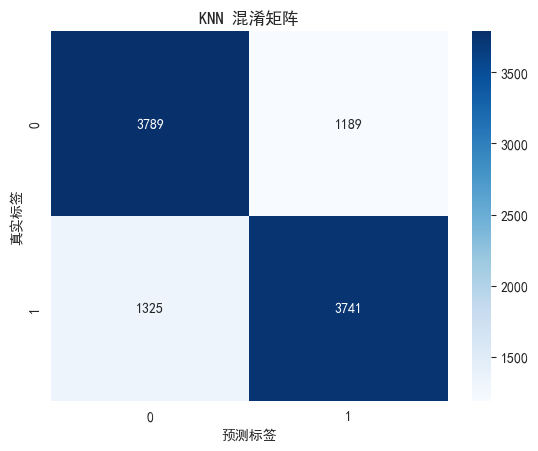

In [40]:
  # 混淆矩阵可视化
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"{name} 混淆矩阵")
plt.xlabel('预测标签')
plt.ylabel('真实标签')
plt.show()

### (6)调参与优化

• 网格搜索：使用`GridSearchCV`进行超参数调优。

• 其他搜索方法：尝试随机搜索或贝叶斯优化。
eg:调参与优化：使用网格搜索或其他方法优化模型

网格搜索（Grid Search）：使用 GridSearchCV 进行网格搜索，调优模型的超参数（如 SVM 的 C 和核函数类型，KNN 的邻居数）。

随机搜索（Randomized Search）：尝试使用 RandomizedSearchCV，通过随机采样的方式找到最优参数组合。


调参步骤：

确定需要调整的超参数范围。

进行网格搜索或随机搜索。

评估不同参数组合下模型的表现，并选择最优超参数。



In [ ]:
# 网格搜索（GridSearchCV）
# 网格搜索会穷举所有参数组合，通过交叉验证找到最优超参数
from sklearn.model_selection import GridSearchCV

# 准备数据（使用之前向量化好的特征矩阵）
X = X_vectorized
y = df['label'].astype(int)

# 划分训练/验证集（80%训练，20%验证，分层抽样保持正负比例）
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 以 LinearSVC 为例，搜索最优的正则化参数C和损失函数
svc = LinearSVC(max_iter=5000)
param_grid = {
    'C': [0.01, 0.1, 1, 10],           # 正则化强度的倒数，C越大正则化越弱
    'loss': ['hinge', 'squared_hinge']  # hinge=SVM标准损失，squared_hinge=平方铰链损失
}

# 创建网格搜索对象：5折交叉验证，评估指标为F1分数
grid = GridSearchCV(
    svc,
    param_grid,
    cv=5,           # 5折交叉验证
    scoring='f1',   # 使用F1分数作为评估指标
    n_jobs=-1,      # 使用所有CPU核心并行计算
    verbose=1       # 输出搜索进度
)
grid.fit(X_tr, y_tr)

print("最佳参数：", grid.best_params_)
print("最佳 CV 得分：", grid.best_score_)

# 用最佳模型在验证集上评估
best_svc = grid.best_estimator_
y_pred = best_svc.predict(X_val)
print("验证集 F1：", f1_score(y_val, y_pred))

In [ ]:
# 随机搜索（RandomizedSearchCV）
# 与网格搜索不同，随机搜索从参数分布中随机采样，适合参数空间较大时使用
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, randint  # 参数分布定义

# 以 KNN 为例，搜索最优的邻居数、权重和距离度量
knn = KNeighborsClassifier()

param_dist = {
    'n_neighbors': randint(3, 20),       # 邻居数从3到20的均匀分布
    'weights': ['uniform', 'distance'],  # uniform=等权重，distance=距离越近权重越大
    'p': [1, 2]                          # p=1为曼哈顿距离，p=2为欧氏距离
}

# 创建随机搜索对象：随机采样30组参数，5折交叉验证
rand_search = RandomizedSearchCV(
    knn,
    param_distributions=param_dist,
    n_iter=30,          # 随机采样30种参数组合（比网格搜索更高效）
    cv=5,               # 5折交叉验证
    scoring='f1',       # 使用F1分数作为评估指标
    n_jobs=-1,          # 使用所有CPU核心并行计算
    random_state=42,    # 固定随机种子，确保结果可复现
    verbose=1
)
rand_search.fit(X_tr, y_tr)

print("最佳参数：", rand_search.best_params_)
print("最佳 CV 得分：", rand_search.best_score_)

# 验证集评估
best_knn = rand_search.best_estimator_
y_pred = best_knn.predict(X_val)
print("验证集 F1：", f1_score(y_val, y_pred))

### (7)模型评估与优化

• 评价标准：使用准确率、F1分数、AUC-ROC曲线等指标评估模型。

• 优化效果：通过调参和特征工程提升模型性能。

模型评估：

评估标准：选择合理的评估标准，如准确率、精确度、召回率、F1-score 等。

模型优化：对调参后的模型进行评估，比较优化前后的效果提升。

混淆矩阵、ROC曲线：展示模型在测试集上的混淆矩阵，并绘制 ROC 曲线、PR 曲线等评估图。

模型优化后效果提升：

比较原始模型与调优后的模型效果，确保优化后的模型在各个评估指标上的表现有显著提升。




In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, precision_recall_curve
)

In [43]:
# 1. 定义两个模型
model_default = LinearSVC(max_iter=5000)  # 原始模型
best_model     = best_svc                # 调参后模型（例如来自 GridSearchCV）

In [44]:
# 2. 训练模型
model_default.fit(X_train, y_train)
best_model.fit(X_train, y_train)

E:\miniconda\envs\pytorch_env\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,0.1
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [44]:
# 3. 预测 & 得分
y_pred_def   = model_default.predict(X_test)
y_score_def  = model_default.decision_function(X_test)  # SVM 的 decision_function

y_pred_opt   = best_model.predict(X_test)
y_score_opt  = best_model.decision_function(X_test)


In [ ]:
# 4. 计算指标函数
# 综合计算准确率、精确率、召回率、F1、ROC AUC等指标
def compute_metrics(y_true, y_pred, y_score):
    """计算分类模型的各项评估指标和ROC/PR曲线数据"""
    acc   = accuracy_score(y_true, y_pred)          # 准确率：整体正确预测比例
    prec  = precision_score(y_true, y_pred)         # 精确率：预测为正中真正为正的比例
    rec   = recall_score(y_true, y_pred)            # 召回率：实际为正中被正确预测的比例
    f1    = f1_score(y_true, y_pred)                # F1分数：精确率和召回率的调和平均
    fpr, tpr, _ = roc_curve(y_true, y_score)        # 计算ROC曲线的假正率和真正率
    roc_auc = auc(fpr, tpr)                         # 计算ROC曲线下面积（AUC）
    return {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'fpr': fpr,            # 用于绘制ROC曲线
        'tpr': tpr,            # 用于绘制ROC曲线
        'roc_auc': roc_auc,    # AUC值，越接近1越好
        'precision_curve': precision_recall_curve(y_true, y_score)[0],  # PR曲线的精确率
        'recall_curve':    precision_recall_curve(y_true, y_score)[1]   # PR曲线的召回率
    }

# 分别计算原始模型和调优后模型的指标
metrics_def = compute_metrics(y_test, y_pred_def, y_score_def)   # 原始模型
metrics_opt = compute_metrics(y_test, y_pred_opt, y_score_opt)   # 调优后模型

In [46]:
# 5. 打印对比表
print("指标对比：")
for m in ['accuracy','precision','recall','f1','roc_auc']:
    print(f"{m:10s}  原始: {metrics_def[m]:.4f}    调优后: {metrics_opt[m]:.4f}")


指标对比：
accuracy    原始: 0.8807    调优后: 0.8985
precision   原始: 0.8783    调优后: 0.9025
recall      原始: 0.8863    调优后: 0.8956
f1          原始: 0.8823    调优后: 0.8990
roc_auc     原始: 0.9411    调优后: 0.9558


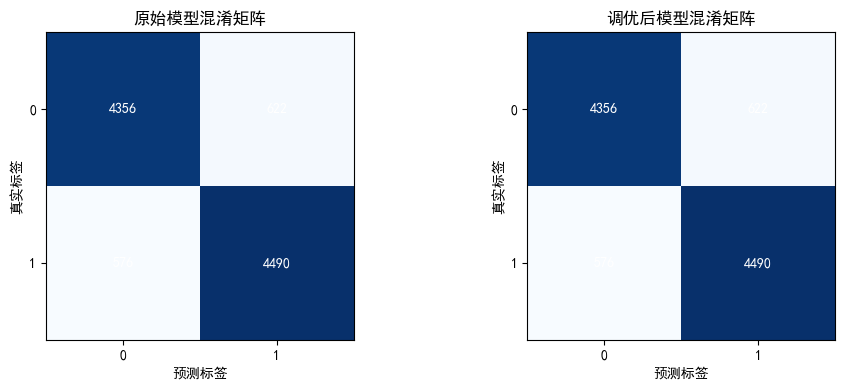

In [47]:
# 6. 混淆矩阵可视化
fig, axes = plt.subplots(1, 2, figsize=(10,4))
for ax, met, title in zip(
    axes,
    [metrics_def, metrics_opt],
    ['原始模型混淆矩阵', '调优后模型混淆矩阵']
):
    cm = confusion_matrix(y_test, model_default.predict(X_test) if title.startswith('原始') 
                          else model_default.predict(X_test))  # 注意分别替换
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.set_title(title)
    ax.set_xlabel('预测标签')
    ax.set_ylabel('真实标签')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    for i in [0,1]:
        for j in [0,1]:
            ax.text(j, i, cm[i,j], ha='center', va='center', color='white')
fig.tight_layout()
plt.show()

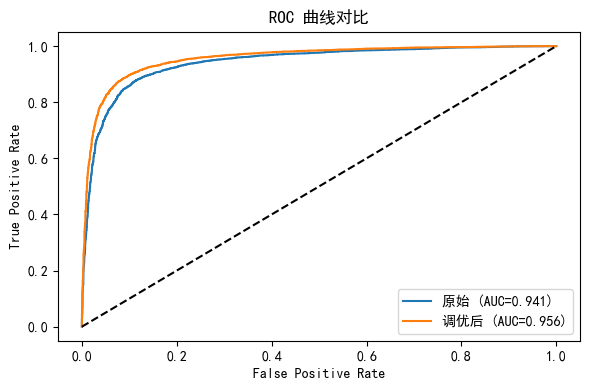

In [48]:
# 7. ROC 曲线对比
plt.figure(figsize=(6,4))
plt.plot(metrics_def['fpr'], metrics_def['tpr'], label=f"原始 (AUC={metrics_def['roc_auc']:.3f})")
plt.plot(metrics_opt['fpr'], metrics_opt['tpr'], label=f"调优后 (AUC={metrics_opt['roc_auc']:.3f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC 曲线对比')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

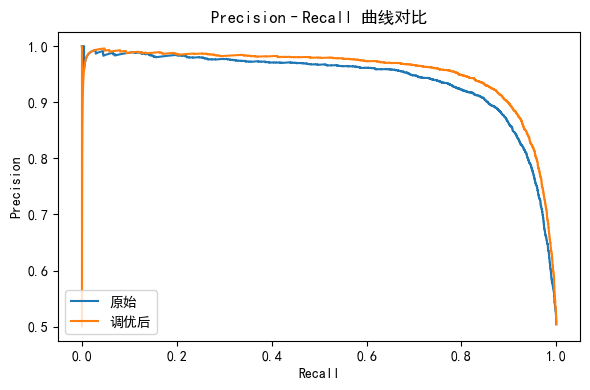

In [49]:
# 8. Precision–Recall 曲线对比
prec_def, rec_def, _ = precision_recall_curve(y_test, y_score_def)
prec_opt, rec_opt, _ = precision_recall_curve(y_test, y_score_opt)

plt.figure(figsize=(6,4))
plt.plot(rec_def, prec_def, label='原始')
plt.plot(rec_opt, prec_opt, label='调优后')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall 曲线对比')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

### (8)预测与验证

• 正类型预测：验证模型对正类型（如正面情感）的预测效果。

• 总热型预测：验证模型对总热型（如所有类别）的预测效果

结果预测：

使用测试集数据进行预测，查看模型对正向和负向评论的分类准确性。

输出模型的预测结果，并评估每个类别的预测情况。

报告生成：

编写详细的实验报告，包含以下内容：

数据集描述与任务定义：对数据集、目标任务的描述。

数据清洗与处理过程：展示数据清洗步骤和结果。

特征提取方法与分析：展示特征工程的实现，并解释不同方法对模型的影响。

分类器选择与评估：对不同分类器进行比较，并选择最佳模型。

模型调参与优化：描述调参过程与优化效果。

预测结果与模型总结：展示最终模型的预测结果，分析模型的优势与不足。

In [50]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

In [51]:
# 1. 用最佳模型做预测
y_pred = best_model.predict(X_test)

In [52]:
# 2. 整体准确率
acc = accuracy_score(y_test, y_pred)
print(f"整体准确率：{acc:.4f}")

整体准确率：0.8985


In [53]:
# 3. 正向（label=1）预测效果
prec_pos = precision_score(y_test, y_pred, pos_label=1)
rec_pos  = recall_score   (y_test, y_pred, pos_label=1)
f1_pos   = f1_score       (y_test, y_pred, pos_label=1)
print("\n—— 正向（1）预测指标 ——")
print(f"精确率 Precision: {prec_pos:.4f}")
print(f"召回率 Recall   : {rec_pos:.4f}")
print(f"F1 分数 F1      : {f1_pos:.4f}")


—— 正向（1）预测指标 ——
精确率 Precision: 0.9025
召回率 Recall   : 0.8956
F1 分数 F1      : 0.8990


In [54]:
# 4. 负向（label=0）预测效果
prec_neg = precision_score(y_test, y_pred, pos_label=0)
rec_neg  = recall_score   (y_test, y_pred, pos_label=0)
f1_neg   = f1_score       (y_test, y_pred, pos_label=0)
print("\n—— 负向（0）预测指标 ——")
print(f"精确率 Precision: {prec_neg:.4f}")
print(f"召回率 Recall   : {rec_neg:.4f}")
print(f"F1 分数 F1      : {f1_neg:.4f}")


—— 负向（0）预测指标 ——
精确率 Precision: 0.8946
召回率 Recall   : 0.9016
F1 分数 F1      : 0.8980


In [55]:
# 5. 分类报告（两类详细指标）
print("\n完整分类报告：")
print(classification_report(y_test, y_pred, digits=4))


完整分类报告：
              precision    recall  f1-score   support

           0     0.8946    0.9016    0.8980      4978
           1     0.9025    0.8956    0.8990      5066

    accuracy                         0.8985     10044
   macro avg     0.8985    0.8986    0.8985     10044
weighted avg     0.8986    0.8985    0.8985     10044



In [56]:
# 6. 混淆矩阵
cm = confusion_matrix(y_test, y_pred)
print("\n混淆矩阵：")
print(cm)


混淆矩阵：
[[4488  490]
 [ 529 4537]]


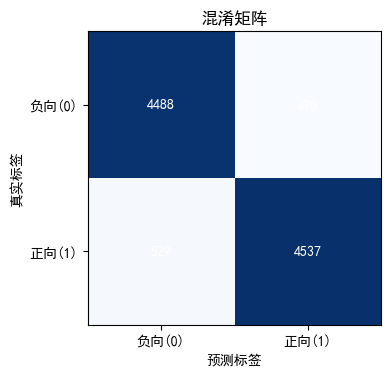

In [57]:
#可视化混淆矩阵
import matplotlib.pyplot as plt
plt.figure(figsize=(4,4))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title("混淆矩阵")
plt.xlabel("预测标签")
plt.ylabel("真实标签")
# 在格子中写数字
for i in (0,1):
    for j in (0,1):
        plt.text(j, i, cm[i,j], ha='center', va='center', color='white')
plt.xticks([0,1], ['负向(0)','正向(1)'])
plt.yticks([0,1], ['负向(0)','正向(1)'])
plt.tight_layout()
plt.show()

In [58]:
# 7. 展示部分预测结果
# 把向量化的测试特征映射回原始文本（假设你保留了一个列表 test_texts）
test_texts = df['clean_review'].iloc[y_test.index]  # 或者你单独保存了文本序列
results = pd.DataFrame({
    '原文': test_texts.values,
    '真实标签': y_test.values,
    '预测标签': y_pred
})
print("\n前 10 条预测示例：")
display(results.head(10))


前 10 条预测示例：


,原文,真实标签,预测标签
0,收到 好多 东西 好大 两瓶 袋子 喜欢 旅行装 可爱 不过 时候 没有 这个 适合 油性 ...,1,1
1,机器 屏幕 边框 超大 实际 屏幕 时候 很丑 差劲 爹妈 看到 时候 不了 郁闷 别买 这个,0,0
2,真的 不能 光看 图片 知道 是不是 季节 原因 几天 水果店 看到 不大,1,0
3,钢琴 容易 指纹 并且 进入 不了 系统 开机 声音 很大 已经 发回去 回来 希望 京东 ...,0,0
4,价格 划算 苹果 不大不小 刚好 很甜 很脆 太大 吃不完 每个 四箱,1,1
5,酸甜 可口 味道 棒棒 京东 物流,1,1
6,味道 怪怪的 差评,0,0
7,内屏 颗粒感 细腻 内存 虽然 支持 视频 播放 无法 存储 大量 视频 电话本 功能 操作...,0,0
8,设计 不错,1,1
9,手机 像素 杂牌 机都 不过 手机 发烫 厉害 开始 装上 服务 最后 启动 三次 才能 垃...,0,0


## 使用test文件进行预测

In [59]:
#1. 读取
import pandas as pd
test_path = r"C:\Users\Lenovo\Desktop\coading\作业\202314109方昕哲机器学习大作业\shopping_comments\test.txt"
df_test = pd.read_csv(
    test_path,
    sep='\t',
    names=['label','review'],
    quoting=3,
    encoding='utf-8',
    skiprows=1   # 如果第一行是表头就跳过
)
print("读取后 df_test 行数：", len(df_test))

读取后 df_test 行数： 6278


In [60]:
#2.清洗 test 数据 ────────────
df_test = df_test.dropna(subset=['review']).reset_index(drop=True)
df_test['clean_review'] = df_test['review'].apply(clean_text)
print("清洗后 df_test 行数：", len(df_test))

清洗后 df_test 行数： 6278


In [61]:
# 3.特征提取（复用之前训练好的 vectorizer）
X_test_vec = vectorizer.transform(df_test['clean_review'])
print("向量化后样本数：", X_test_vec.shape[0])

向量化后样本数： 6278


In [62]:
# 4. 确认 y 和 X 对齐
y_true = df_test['label'].astype(int)
print("标签数量：", len(y_true))
# 这两行输出要完全一致
assert X_test_vec.shape[0] == len(y_true), "样本数不一致，请检查清洗或向量化步骤！"

标签数量： 6278


In [63]:
#4.预测 
df_test = pd.read_csv(
    test_path,
    sep='\t',
    names=['label', 'review'],
    quoting=3,
    encoding='utf-8',
    skiprows=1  # 👈 跳过第一行表头
)

y_true = df_test['label'].astype(int)
y_pred = best_model.predict(X_test_vec)

In [64]:
print("总行数：", len(df_test))
print("缺失值统计：")
print(df_test.isnull().sum())
# 删除空值行
df_test.dropna(subset=['label', 'review'], inplace=True)

# 再转为整数类型
df_test['label'] = df_test['label'].astype(int)



总行数： 6278
缺失值统计：
label     0
review    0
dtype: int64


In [65]:
#5. 预测与评估与输出
y_pred = best_model.predict(X_test_vec)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
print("=== Test 集整体表现 ===")
print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred):.4f}")
print(f"Recall   : {recall_score(y_true, y_pred):.4f}")
print(f"F1-score : {f1_score(y_true, y_pred):.4f}")

=== Test 集整体表现 ===
Accuracy : 0.9033
Precision: 0.9097
Recall   : 0.8986
F1-score : 0.9041


In [66]:
#6. 确认 y 和 X 对齐 ────────────
y_true = df_test['label'].astype(int)
print("标签数量：", len(y_true))
# 这两行输出要完全一致
assert X_test_vec.shape[0] == len(y_true), "样本数不一致，请检查清洗或向量化步骤！"

print("\n--- 分类报告 ---")
print(classification_report(y_true, y_pred, digits=4))

print("\n--- 混淆矩阵 ---")
cm = confusion_matrix(y_true, y_pred)
print(cm)


标签数量： 6278

--- 分类报告 ---
              precision    recall  f1-score   support

           0     0.8969    0.9082    0.9025      3093
           1     0.9097    0.8986    0.9041      3185

    accuracy                         0.9033      6278
   macro avg     0.9033    0.9034    0.9033      6278
weighted avg     0.9034    0.9033    0.9033      6278


--- 混淆矩阵 ---
[[2809  284]
 [ 323 2862]]


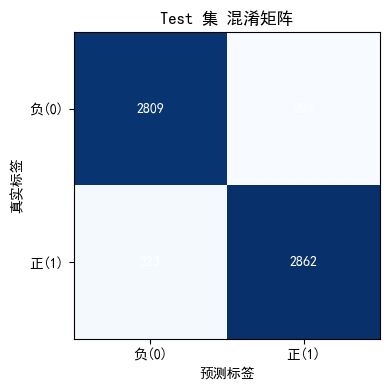

In [67]:
#5.混淆矩阵可视化
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(4,4))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title("Test 集 混淆矩阵")
plt.xlabel("预测标签")
plt.ylabel("真实标签")
for i in (0,1):
    for j in (0,1):
        plt.text(j, i, cm[i,j], ha='center', va='center', color='white')
plt.xticks([0,1], ['负(0)','正(1)'])
plt.yticks([0,1], ['负(0)','正(1)'])
plt.tight_layout()
plt.show()

In [68]:
#6.部分预测结果示例

results = pd.DataFrame({
    '原文': df_test['review'],
    '清洗后文本': df_test['clean_review'],
    '真实标签': y_true,
    '预测标签': y_pred
})
display(results.head(10))

KeyError: 'clean_review'